1. Setup and Class Distribution

Fraud vs Legitimate counts:
class
0    136961
1     14151
Name: count, dtype: int64


C:\Users\Home-User\AppData\Local\Temp\ipykernel_3868\2847165888.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='class', data=df, palette='magma')


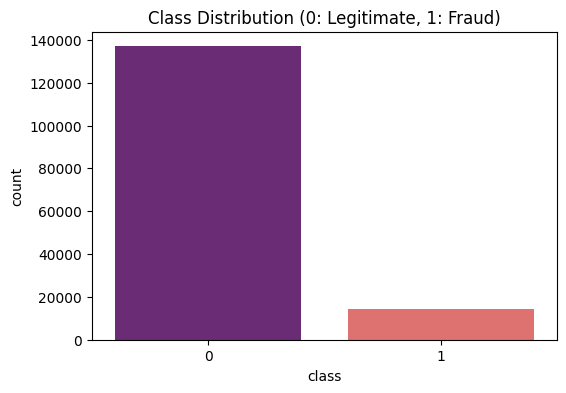

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load the processed data
df = pd.read_csv('../data/processed/processed_fraud_data.csv')

# --- Requirement: Class Distribution Analysis ---
print("Fraud vs Legitimate counts:")
print(df['class'].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x='class', data=df, palette='magma')
plt.title('Class Distribution (0: Legitimate, 1: Fraud)')
plt.show()

2. Univariate Analysis

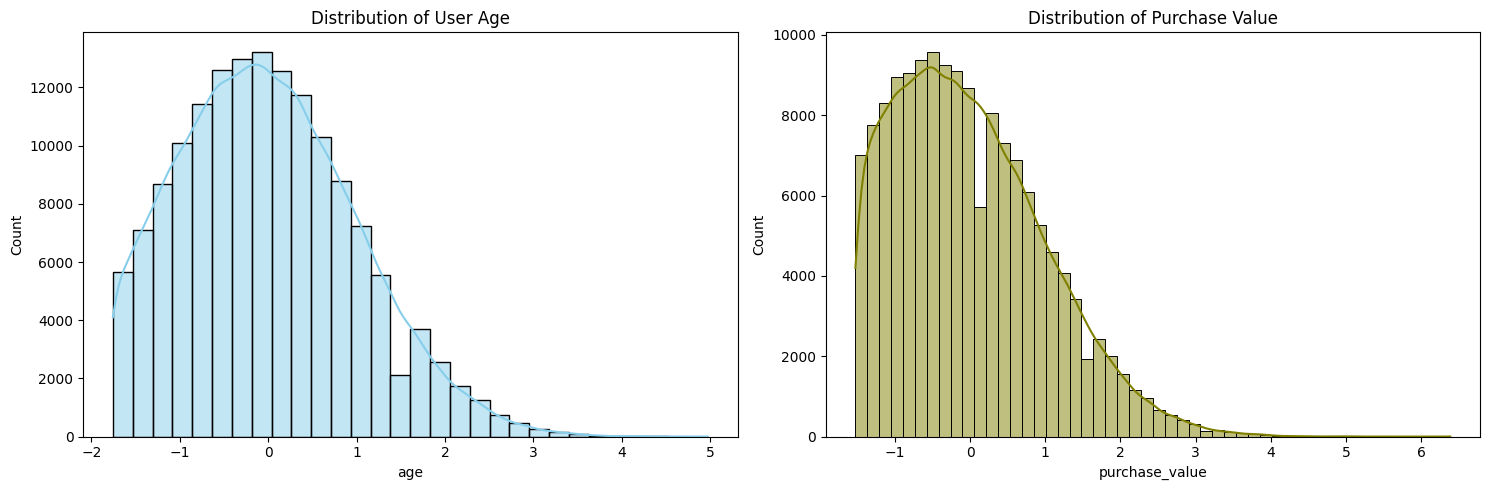

In [2]:
# --- Requirement: Univariate Analysis ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Distribution of Age
sns.histplot(df['age'], bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of User Age')

# Distribution of Purchase Value
sns.histplot(df['purchase_value'], bins=50, kde=True, ax=axes[1], color='olive')
axes[1].set_title('Distribution of Purchase Value')

plt.tight_layout()
plt.show()

3. Bivariate Analysis & Geolocation Patterns

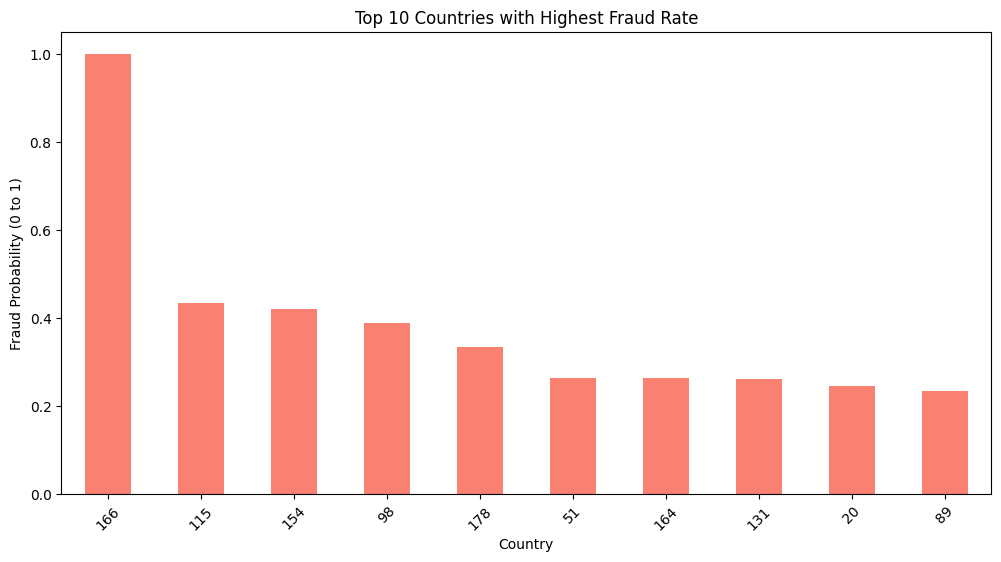

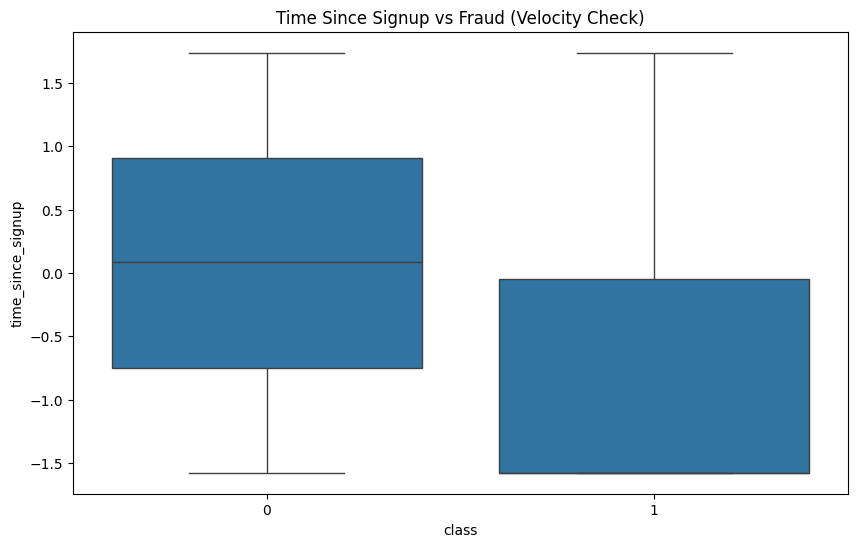

In [3]:
# --- Requirement: Bivariate Analysis & Geolocation ---

# 1. Fraud Rate by Country (Top 10)
# We calculate the mean of the 'class' column per country
country_fraud = df.groupby('country')['class'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
country_fraud.plot(kind='bar', color='salmon')
plt.title('Top 10 Countries with Highest Fraud Rate')
plt.ylabel('Fraud Probability (0 to 1)')
plt.xlabel('Country')
plt.xticks(rotation=45)
plt.show()

# 2. Time Since Signup vs Fraud
# Checking if rapid purchases (low time_since_signup) correlate with fraud
plt.figure(figsize=(10, 6))
sns.boxplot(x='class', y='time_since_signup', data=df)
plt.title('Time Since Signup vs Fraud (Velocity Check)')
plt.show()

4. Correlation Analysis

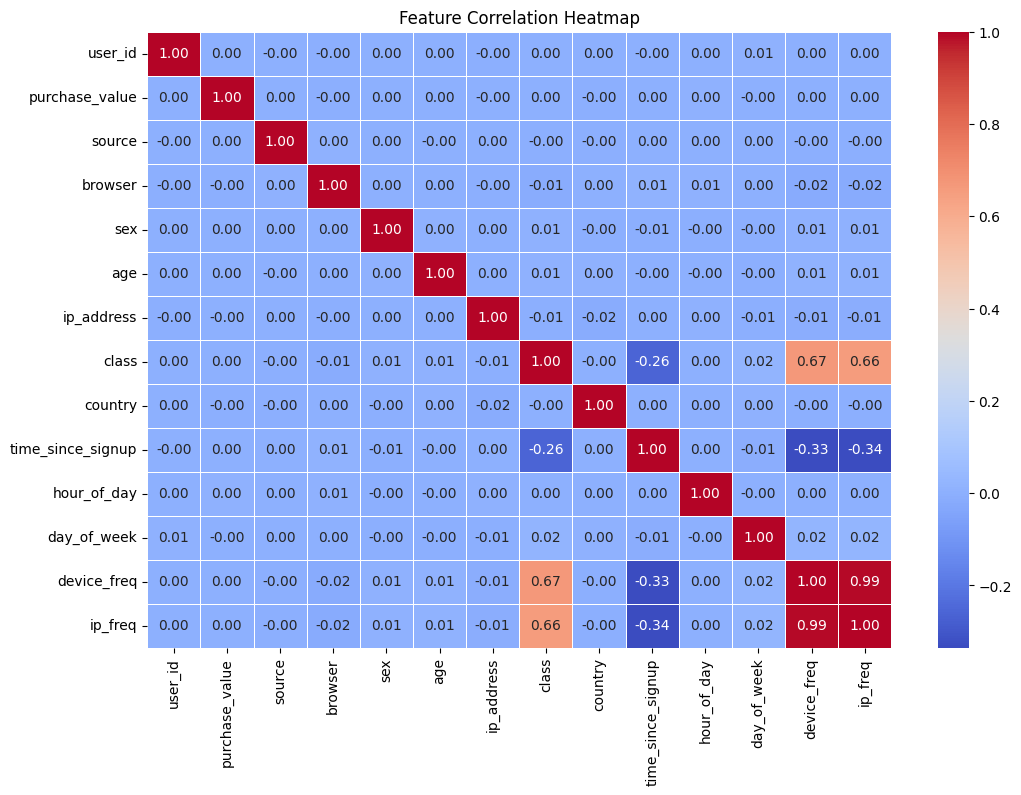

In [4]:
plt.figure(figsize=(12, 8))
# Select only numeric columns for correlation
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()